In [ ]:
!pip install xgboost
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
heart_data = pd.read_csv("heart.csv")

diabetes_data = pd.read_csv("diabetes.csv")

cancer_data = pd.read_csv("data.csv")
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for column in columns_to_replace:
    diabetes_data[column] = diabetes_data[column].replace(
        0,
        diabetes_data[column].median()
    )
    print((diabetes_data[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum())

Glucose            0
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Glucose            0
BloodPressure      0
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Glucose            0
BloodPressure      0
SkinThickness      0
Insulin          374
BMI               11
dtype: int64
Glucose           0
BloodPressure     0
SkinThickness     0
Insulin           0
BMI              11
dtype: int64
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [ ]:
print(heart_data.head())

print(diabetes_data.head())

print(cancer_data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35     30.5  33.6   
1            1       85             66             29     30.5  26.6   
2            8      183             64             23     30.5  23.3   
3            1       89             66             23     94.0  28.1   
4            0      1

In [ ]:
print(heart_data.info())

print(diabetes_data.info())

print(cancer_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----

In [ ]:
print(heart_data.isnull().sum())

print(diabetes_data.isnull().sum())

print(cancer_data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_s

In [ ]:
if 'Unnamed: 32' in cancer_data.columns:
    cancer_data.drop('Unnamed: 32', axis=1, inplace=True)

if 'id' in cancer_data.columns:
    cancer_data.drop('id', axis=1, inplace=True)

if cancer_data['diagnosis'].dtype == 'object':
    cancer_data['diagnosis'] = cancer_data['diagnosis'].map({
        'M': 1,
        'B': 0
    })

In [ ]:
def train_and_evaluate(data, target_column, dataset_name):

    print("\n================================================")
    print(f"{dataset_name} DATASET")
    print("================================================")

    X = data.drop(target_column, axis=1)
    y = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
    smote = SMOTE(random_state=42)

    X_train, y_train = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM": SVC(),
        "Random Forest": RandomForestClassifier(),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    }

    for name, model in models.items():

        print("\n--------------------------------------")
        print(f"MODEL: {name}")
        print("--------------------------------------")

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        precision = precision_score(y_test, y_pred)

        recall = recall_score(y_test, y_pred)

        f1 = f1_score(y_test, y_pred)

        print(f"Accuracy  : {accuracy:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1 Score  : {f1:.4f}")

        print("\nClassification Report")
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)

        print("\nConfusion Matrix")
        print(cm)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)

        disp.plot()

        plt.title(f"{dataset_name} - {name}")

        plt.show()


Heart Disease DATASET

--------------------------------------
MODEL: Logistic Regression
--------------------------------------
Accuracy  : 0.8049
Precision : 0.7692
Recall    : 0.8738
F1 Score  : 0.8182

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       102
           1       0.77      0.87      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205


Confusion Matrix
[[75 27]
 [13 90]]


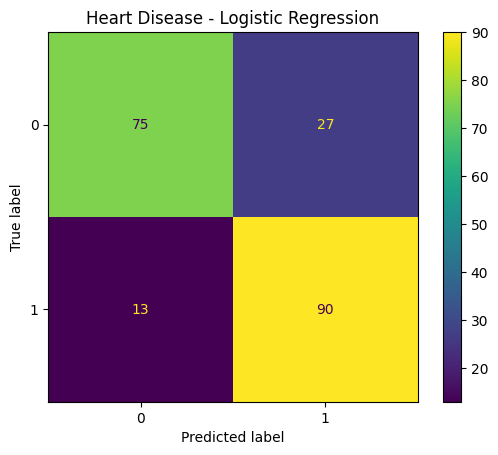


--------------------------------------
MODEL: SVM
--------------------------------------
Accuracy  : 0.8878
Precision : 0.8509
Recall    : 0.9417
F1 Score  : 0.8940

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205


Confusion Matrix
[[85 17]
 [ 6 97]]


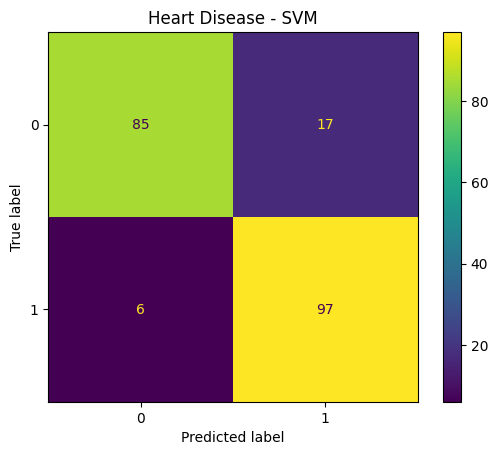


--------------------------------------
MODEL: Random Forest
--------------------------------------
Accuracy  : 0.9854
Precision : 1.0000
Recall    : 0.9709
F1 Score  : 0.9852

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


Confusion Matrix
[[102   0]
 [  3 100]]


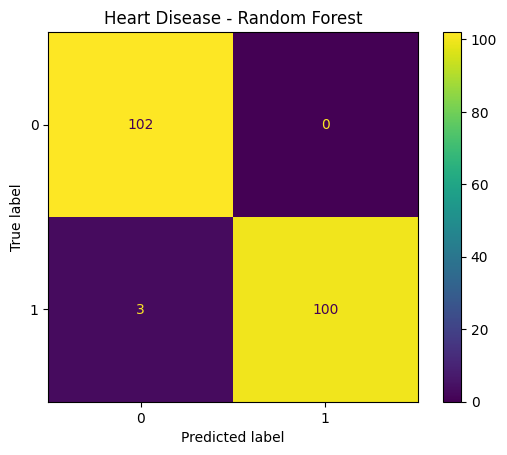


--------------------------------------
MODEL: XGBoost
--------------------------------------
Accuracy  : 0.9854
Precision : 1.0000
Recall    : 0.9709
F1 Score  : 0.9852

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


Confusion Matrix
[[102   0]
 [  3 100]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:30:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


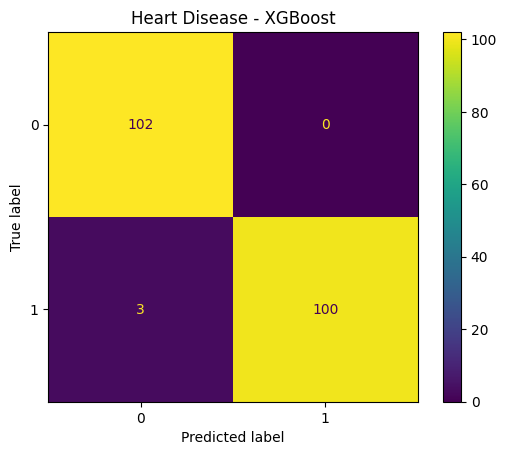

In [ ]:
train_and_evaluate(
    heart_data,
    "target",
    "Heart Disease"
)


Diabetes DATASET

--------------------------------------
MODEL: Logistic Regression
--------------------------------------
Accuracy  : 0.7078
Precision : 0.5735
Recall    : 0.7091
F1 Score  : 0.6341

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.71      0.76        99
           1       0.57      0.71      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154


Confusion Matrix
[[70 29]
 [16 39]]


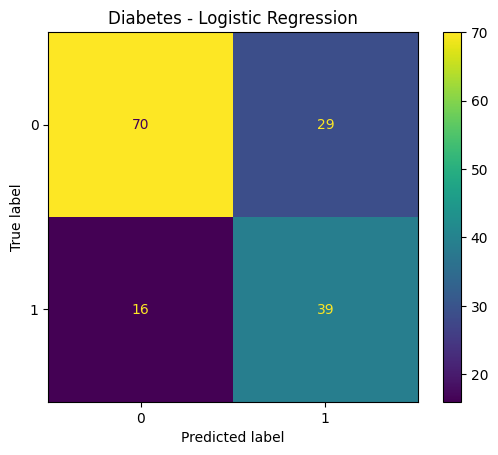


--------------------------------------
MODEL: SVM
--------------------------------------
Accuracy  : 0.7403
Precision : 0.6056
Recall    : 0.7818
F1 Score  : 0.6825

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.72      0.78        99
           1       0.61      0.78      0.68        55

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154


Confusion Matrix
[[71 28]
 [12 43]]


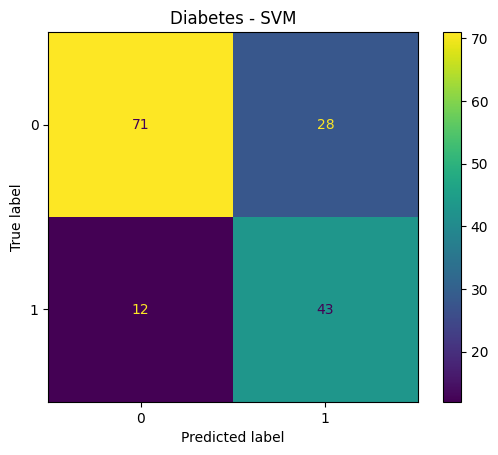


--------------------------------------
MODEL: Random Forest
--------------------------------------
Accuracy  : 0.7727
Precision : 0.6515
Recall    : 0.7818
F1 Score  : 0.7107

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.77      0.81        99
           1       0.65      0.78      0.71        55

    accuracy                           0.77       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.79      0.77      0.78       154


Confusion Matrix
[[76 23]
 [12 43]]


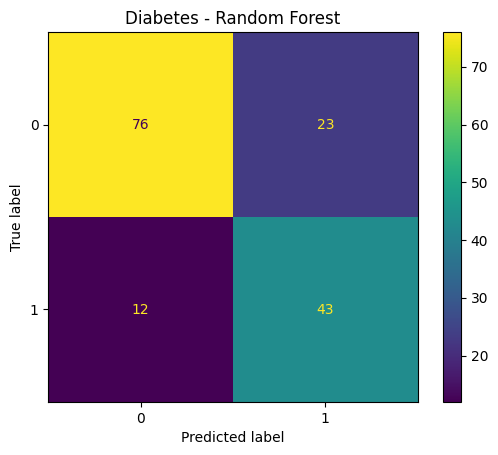


--------------------------------------
MODEL: XGBoost
--------------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:30:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy  : 0.7208
Precision : 0.5833
Recall    : 0.7636
F1 Score  : 0.6614

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.70      0.76        99
           1       0.58      0.76      0.66        55

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154


Confusion Matrix
[[69 30]
 [13 42]]


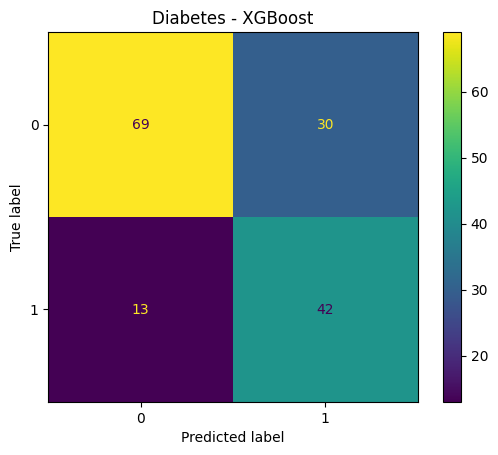

In [ ]:
train_and_evaluate(
    diabetes_data,
    "Outcome",
    "Diabetes"
)


Breast Cancer DATASET

--------------------------------------
MODEL: Logistic Regression
--------------------------------------
Accuracy  : 0.9825
Precision : 0.9767
Recall    : 0.9767
F1 Score  : 0.9767

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix
[[70  1]
 [ 1 42]]


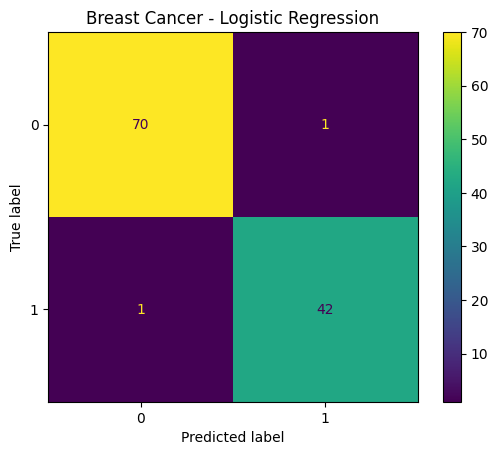


--------------------------------------
MODEL: SVM
--------------------------------------
Accuracy  : 0.9561
Precision : 0.9318
Recall    : 0.9535
F1 Score  : 0.9425

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix
[[68  3]
 [ 2 41]]


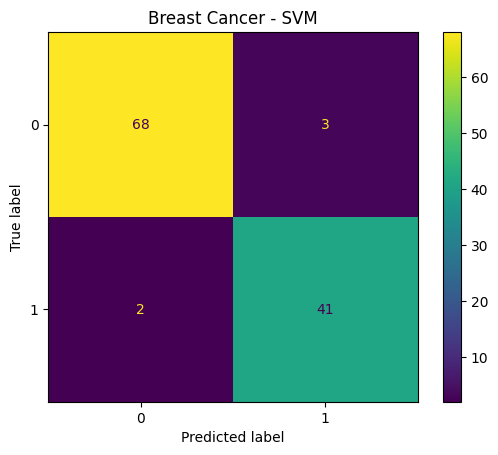


--------------------------------------
MODEL: Random Forest
--------------------------------------
Accuracy  : 0.9649
Precision : 0.9535
Recall    : 0.9535
F1 Score  : 0.9535

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix
[[69  2]
 [ 2 41]]


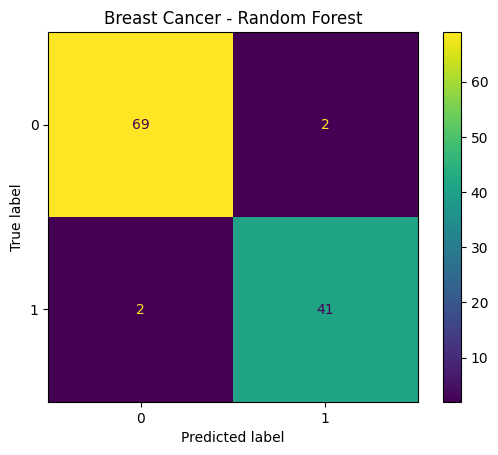


--------------------------------------
MODEL: XGBoost
--------------------------------------
Accuracy  : 0.9561
Precision : 0.9524
Recall    : 0.9302
F1 Score  : 0.9412

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix
[[69  2]
 [ 3 40]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:31:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


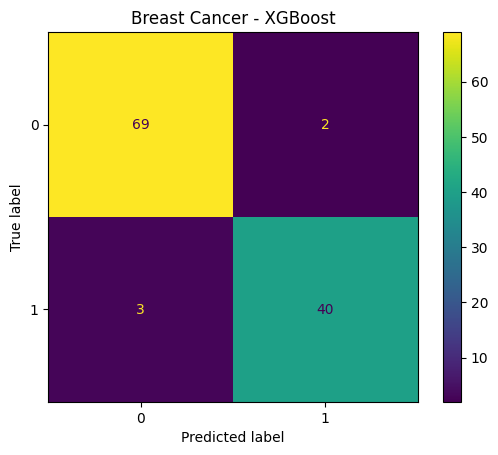

In [ ]:
train_and_evaluate(
    cancer_data,
    "diagnosis",
    "Breast Cancer"
)